In [1]:
# NASA Kepler Exoplanet Classification
# Model Training

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/cleaned_koi.csv")

In [4]:
X = df.drop("koi_disposition", axis=1)

y = df["koi_disposition"]

In [5]:
X = pd.get_dummies(
    X,
    columns=[
        "koi_fittype",
        "koi_parm_prov",
        "koi_sparprov"
    ],
    drop_first=True,
    dtype=int
)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](110,)","['koi_fpflag_nt','koi_fpflag_ss','koi_fpflag_co',..., 'koi_sparprov_q1_q17_dr25_stellar','koi_sparprov_stellar_q1_q16', 'koi_sparprov_stellar_q1_q17']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,110
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [8]:
y_pred = pipeline.predict(X_test)

In [9]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9174072138003136
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       396
           1       0.86      0.88      0.87       549
           2       0.99      0.99      0.99       968

    accuracy                           0.92      1913
   macro avg       0.89      0.89      0.89      1913
weighted avg       0.92      0.92      0.92      1913

[[312  78   6]
 [ 63 483   3]
 [  8   0 960]]


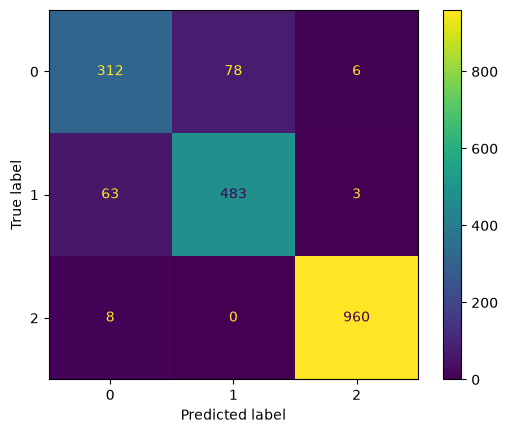

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

In [11]:
"""Logistic Regression:
Observations:
- Accuracy = 91.74%
- Excellent performance on FALSE POSITIVE.
- Confuses CANDIDATE and CONFIRMED."""

'Logistic Regression:\nObservations:\n- Accuracy = 91.74%\n- Excellent performance on FALSE POSITIVE.\n- Confuses CANDIDATE and CONFIRMED.'

In [12]:
"""Decision Tree Model"""

'Decision Tree Model'

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.9053842132775745
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       396
           1       0.85      0.86      0.85       549
           2       0.98      0.99      0.99       968

    accuracy                           0.91      1913
   macro avg       0.87      0.87      0.87      1913
weighted avg       0.90      0.91      0.91      1913

[[306  76  14]
 [ 76 470   3]
 [  4   8 956]]


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.9268165185572399
              precision    recall  f1-score   support

           0       0.86      0.79      0.82       396
           1       0.91      0.90      0.90       549
           2       0.96      1.00      0.98       968

    accuracy                           0.93      1913
   macro avg       0.91      0.90      0.90      1913
weighted avg       0.93      0.93      0.93      1913

[[313  49  34]
 [ 51 495   3]
 [  2   1 965]]


In [15]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

top_features = importance.head(30)["Feature"].tolist()

print(top_features)

['koi_fpflag_nt', 'koi_fpflag_co', 'koi_fpflag_ss', 'koi_dikco_msky', 'koi_dicco_msky', 'koi_smet_err2', 'koi_model_snr', 'koi_max_mult_ev', 'koi_prad', 'koi_ror', 'koi_steff_err1', 'koi_dor', 'koi_fwm_sdec_err', 'koi_prad_err2', 'koi_prad_err1', 'koi_fwm_stat_sig', 'koi_count', 'koi_fpflag_ec', 'koi_duration_err1', 'koi_steff_err2', 'koi_smet_err1', 'koi_fwm_sdeco_err', 'koi_duration_err2', 'koi_dikco_mra_err', 'koi_time0bk_err1', 'koi_fwm_srao_err', 'koi_time0_err2', 'koi_dikco_mdec_err', 'koi_dicco_msky_err', 'koi_time0_err1']


In [16]:
X_selected = X[top_features]

In [17]:
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
rf_new = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_new.fit(X_train_selected, y_train_selected)

y_pred = rf_new.predict(X_test_selected)

print("Accuracy:", accuracy_score(y_test_selected, y_pred))

Accuracy: 0.9372713016204913


In [19]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf_new,
    X_selected,
    y,
    cv=cv,
    scoring='accuracy'
)

print(scores)
print(scores.mean())
print(scores.std())

[0.93047569 0.94197595 0.93570308 0.94772608 0.94037657]
0.9392514769021473
0.00583289062924859


In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    'n_estimators': [100, 200, 300, 500, 700],
    'max_depth': [10, 20, 30, 40, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

In [21]:
rf = RandomForestClassifier(random_state=42)

In [22]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring='accuracy',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_selected, y_train_selected)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be

In [23]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Accuracy:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}

Best CV Accuracy:
0.9383085086854251


In [24]:
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test_selected)

from sklearn.metrics import accuracy_score

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.9372713016204913


In [25]:
importance = pd.DataFrame({
    "Feature": X_train_selected.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

              Feature  Importance
0       koi_fpflag_nt    0.125897
1       koi_fpflag_co    0.084327
2       koi_fpflag_ss    0.078326
8            koi_prad    0.046084
6       koi_model_snr    0.044945
4      koi_dicco_msky    0.043855
3      koi_dikco_msky    0.043636
7     koi_max_mult_ev    0.042598
9             koi_ror    0.041042
5       koi_smet_err2    0.035802
11            koi_dor    0.030484
18  koi_duration_err1    0.030313
10     koi_steff_err1    0.029367
17      koi_fpflag_ec    0.028840
15   koi_fwm_stat_sig    0.027082
22  koi_duration_err2    0.025361
13      koi_prad_err2    0.023121
14      koi_prad_err1    0.022958
21  koi_fwm_sdeco_err    0.021896
12   koi_fwm_sdec_err    0.019185


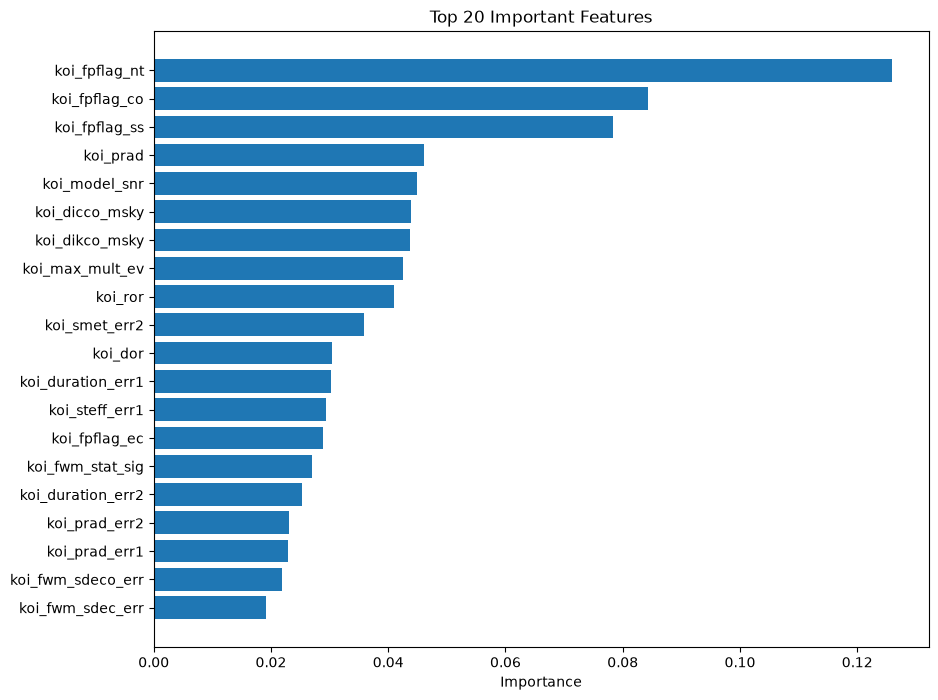

In [26]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(10,8))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 20 Important Features")
plt.show()

In [27]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss",
    tree_method="hist"
)

In [28]:
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9451123889179299


In [29]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
60,koi_smet_err2,0.139198
107,koi_sparprov_q1_q17_dr25_stellar,0.107254
0,koi_fpflag_nt,0.094137
2,koi_fpflag_co,0.091407
1,koi_fpflag_ss,0.074637
47,koi_model_snr,0.039084
102,koi_fittype_LS+MCMC,0.035048
3,koi_fpflag_ec,0.033868
29,koi_prad,0.024766
94,koi_dicco_msky,0.018156


In [30]:
top_features = importance.head(20)["Feature"].tolist()

In [31]:
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

xgb.fit(X_train_selected, y_train)

y_pred = xgb.predict(X_test_selected)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9404077365394669


In [32]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    "n_estimators": [200, 300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3, 0.5]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="mlogloss"
    ),
    param_distributions=param_dist,
    n_iter=30,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can 

In [33]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Accuracy:")
print(random_search.best_score_)

Best Parameters:
{'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}

Best CV Accuracy:
0.9469348497073552


In [34]:
best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(X_test)

from sklearn.metrics import accuracy_score

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.9414532148457919


In [35]:
from sklearn.model_selection import train_test_split

X_train_es, X_val, y_train_es, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [36]:
import xgboost
print(xgboost.__version__)

3.3.0


In [37]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss",
    early_stopping_rounds=20
)

xgb.fit(
    X_train_es,
    y_train_es,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_

In [38]:
print("Best iteration:", xgb.best_iteration)

Best iteration: 203


In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Predictions
y_pred = model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall   : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1 Score : {f1:.4f} ({f1*100:.2f}%)")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9456 (94.56%)
Precision: 0.9453 (94.53%)
Recall   : 0.9456 (94.56%)
F1 Score : 0.9454 (94.54%)

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.86      0.87       396
           1       0.91      0.92      0.92       549
           2       0.99      1.00      0.99       968

    accuracy                           0.95      1913
   macro avg       0.93      0.92      0.93      1913
weighted avg       0.95      0.95      0.95      1913



In [44]:
import joblib

# Save model
joblib.dump(xgb, "../model.joblib")

# Save training columns
joblib.dump(list(X.columns), "../training_columns.joblib")

# Save mapping
target_mapping = {
    "CANDIDATE": 0,
    "CONFIRMED": 1,
    "FALSE POSITIVE": 2
}
joblib.dump(target_mapping, "../target_mapping.joblib")

['../target_mapping.joblib']

In [45]:
import joblib
import pandas as pd

# -----------------------------
# Load saved files
# -----------------------------
model = joblib.load("../model.joblib")
training_columns = joblib.load("../training_columns.joblib")
target_mapping = joblib.load("../target_mapping.joblib")

inverse_mapping = {v: k for k, v in target_mapping.items()}

# -----------------------------
# Load new data
# -----------------------------
df = pd.read_csv("../data/KOI_Cumulative_clean.csv")

# -----------------------------
# Drop columns exactly like training
# -----------------------------
drop_cols = [
    "kepoi_name",
    "kepler_name",
    "koi_vet_stat",
    "koi_vet_date",
    "koi_disposition",
    "koi_disp_prov",
    "koi_comment",
    "koi_limbdark_mod",
    "koi_tce_delivname",
    "koi_quarters",
    "koi_trans_mod",
    "koi_datalink_dvr",
    "koi_datalink_dvs"
]

df = df.drop(columns=drop_cols, errors="ignore")

# -----------------------------
# One-hot encoding
# -----------------------------
df = pd.get_dummies(
    df,
    columns=[
        "koi_fittype",
        "koi_parm_prov",
        "koi_sparprov"
    ],
    drop_first=True,
    dtype=int
)

# -----------------------------
# Match training columns
# -----------------------------
df = df.reindex(columns=training_columns, fill_value=0)

# -----------------------------
# Predict
# -----------------------------
pred = model.predict(df)

pred_labels = [inverse_mapping[int(x)] for x in pred]

# -----------------------------
# Save predictions
# -----------------------------
output = pd.DataFrame({
    "Prediction": pred_labels
})

output.to_csv("predictions.csv", index=False)

print(output.head())
print("\nPredictions saved successfully!")

       Prediction
0       CONFIRMED
1       CONFIRMED
2       CANDIDATE
3  FALSE POSITIVE
4       CONFIRMED

Predictions saved successfully!


In [46]:
import os
print(os.getcwd())

c:\Users\haris\Downloads\Exoplanet-Classification\Exoplanet-Classification\notebooks
